<a href="https://colab.research.google.com/github/dnp1508-prog/Clasificaci-n-de-eventos-higgs-con-ML/blob/main/higgs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

target
1    51827
0    46223
Name: count, dtype: int64
9


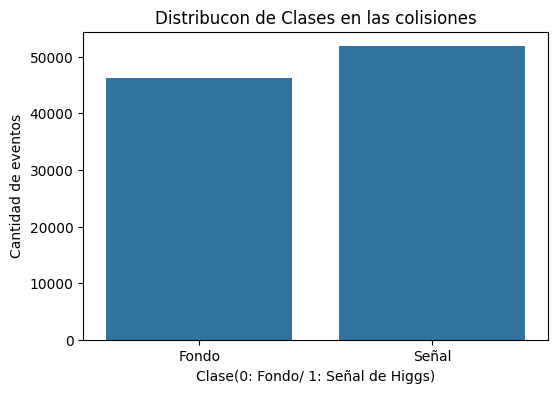

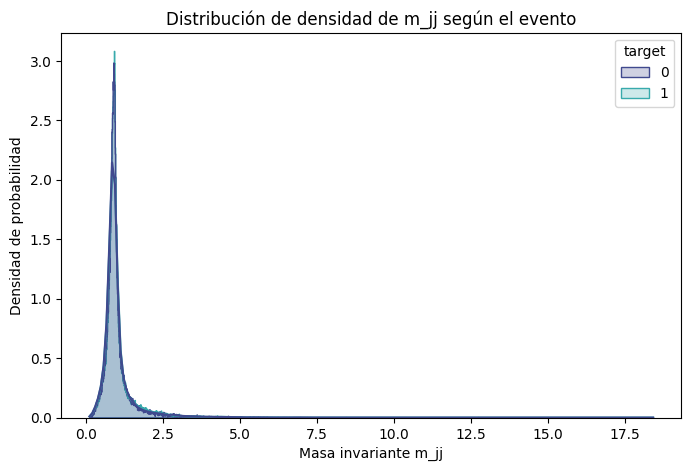

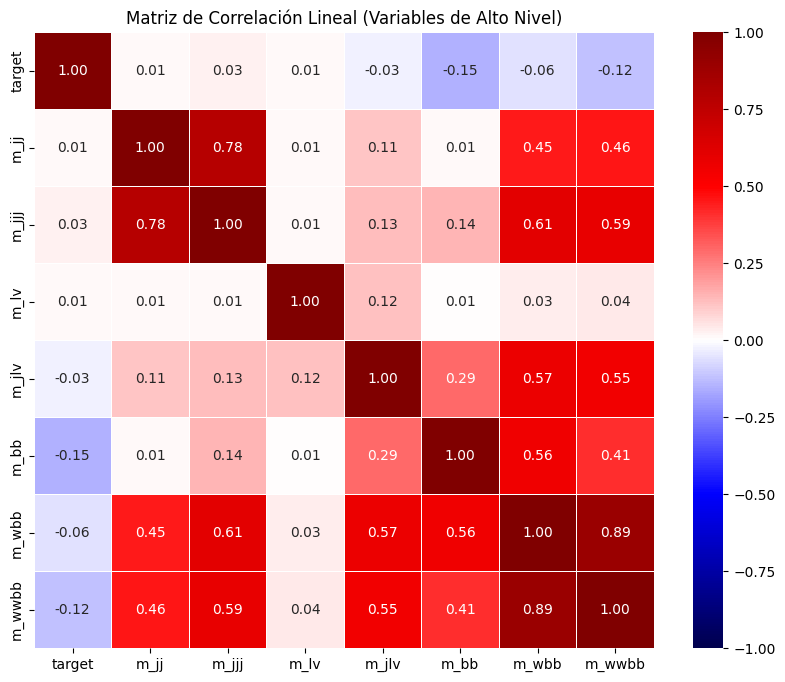

(78440, 28) (78440,)
Muestras asignadas a Entrenamiento: 78440
Muestras asignadas a Prueba: 19610
Reporte de evaluación de  Regresión Logística
Matriz de Confusión:
   [Veraderos Negativos (Fondo correcto): 4844 | Falsos Positivos (Ruido colado): 4401]
   [Falsos Negativos (Higgs perdido): 2689 | Verdaderos Positivos (Higgs correcto): 7676]
Métricas de clasificación: 
              precision    recall  f1-score   support

    Fondo(0)       0.64      0.52      0.58      9245
    Señal(1)       0.64      0.74      0.68     10365

    accuracy                           0.64     19610
   macro avg       0.64      0.63      0.63     19610
weighted avg       0.64      0.64      0.63     19610

Reporte de evaluación de  Árbol de decision
Matriz de Confusión:
   [Veraderos Negativos (Fondo correcto): 5199 | Falsos Positivos (Ruido colado): 4046]
   [Falsos Negativos (Higgs perdido): 2675 | Verdaderos Positivos (Higgs correcto): 7690]
Métricas de clasificación: 
              precision    reca

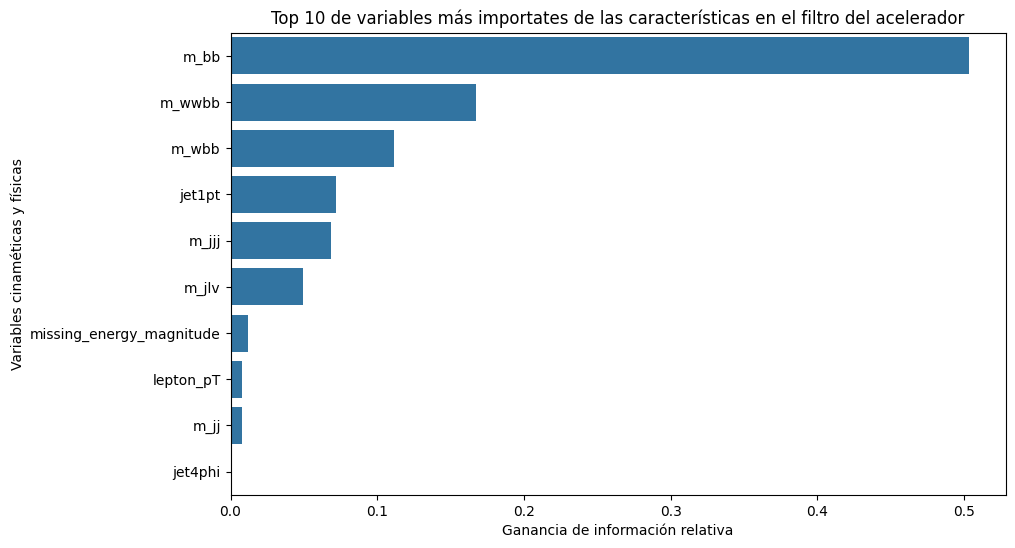

AUC Regresión Logística: 0.681
AUC Árbol: 0.719
AUC Árbol optimizado: 0.720


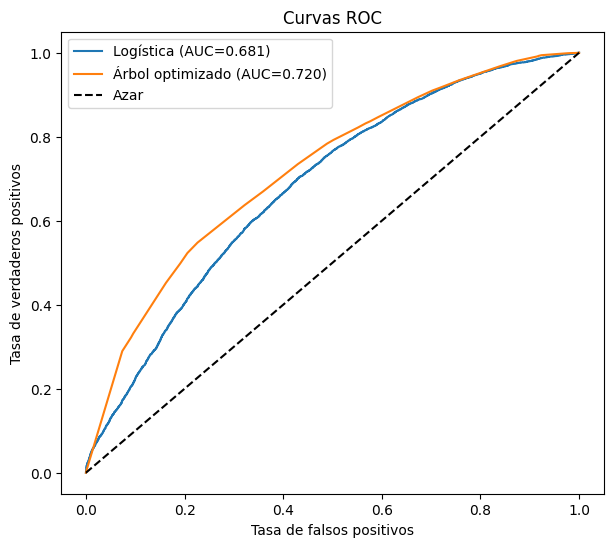

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer

data = fetch_openml(data_id=23512, as_frame=True)
df = data.frame
df['target'] = df['class'].astype(float).astype(int)
df = df.drop(columns=['class'])

print(df['target'].value_counts())
print(df.isnull().sum().sum())   # debería ser 0

x = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
x_escalado = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

df_procesado = pd.concat([y, x_escalado], axis=1)

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_procesado)
plt.title('Distribucon de Clases en las colisiones')
plt.xlabel('Clase(0: Fondo/ 1: Señal de Higgs)')
plt.ylabel('Cantidad de eventos')
plt.xticks(ticks=[0, 1], labels=['Fondo', 'Señal'])
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='m_jj', hue='target', kde=True, element='step',
             stat='density', common_norm=False, palette='mako')
plt.title('Distribución de densidad de m_jj según el evento')
plt.xlabel('Masa invariante m_jj')
plt.ylabel('Densidad de probabilidad')
plt.show()

plt.figure(figsize=(10, 8))
high_level_cols = ['target', 'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']
corr_matrix = df[high_level_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='seismic', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación Lineal (Variables de Alto Nivel)')
plt.show()

x_final = df_procesado.drop(columns=['target'])
y_final = df_procesado['target']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

x_train = pd.DataFrame(scaler.fit_transform(imputer.fit_transform(x_train)), columns=x.columns)
x_test = pd.DataFrame(scaler.transform(imputer.transform(x_test)), columns=x.columns)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
print(x_train.shape, y_train.shape)

print(f"Muestras asignadas a Entrenamiento: {x_train.shape[0]}")
print(f"Muestras asignadas a Prueba: {x_test.shape[0]}")

modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)

modelo_logistico.fit(x_train, y_train)
modelo_arbol.fit(x_train, y_train)

y_pred_log = modelo_logistico.predict(x_test)
y_pred_tree = modelo_arbol.predict(x_test)

def evaluar_modelo(nombre_modelo, y_real, y_pred):
    print('Reporte de evaluación de ', nombre_modelo)

    cm = confusion_matrix(y_real, y_pred)
    print("Matriz de Confusión:")
    print(f"   [Veraderos Negativos (Fondo correcto): {cm[0][0]} | Falsos Positivos (Ruido colado): {cm[0][1]}]")
    print(f"   [Falsos Negativos (Higgs perdido): {cm[1][0]} | Verdaderos Positivos (Higgs correcto): {cm[1][1]}]")

    print('Métricas de clasificación: ')
    print(classification_report(y_real, y_pred, target_names=['Fondo(0)', 'Señal(1)']))

evaluar_modelo('Regresión Logística', y_test, y_pred_log)
evaluar_modelo('Árbol de decision', y_test, y_pred_tree)

param_grid_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_tree,
    cv=5,
    scoring='recall',
    n_jobs=1
)

grid_search_tree.fit(x_train, y_train)
print(f"Mejores hiperparámetros encontrados para el Árbol: {grid_search_tree.best_params_}")

mejor_arbol = grid_search_tree.best_estimator_
y_pred_tree_opt = mejor_arbol.predict(x_test)

evaluar_modelo('Árbol de decisión optimizado', y_test, y_pred_tree_opt)

importancia = mejor_arbol.feature_importances_
indices = np.argsort(importancia)[::-1]

top_features = [x_train.columns[i] for i in indices[:10]]
top_importancias = importancia[indices[:10]]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importancias, y=top_features)
plt.title('Top 10 de variables más importates de las características en el filtro del acelerador')
plt.xlabel('Ganancia de información relativa')
plt.ylabel('Variables cinaméticas y físicas')
plt.show()

auc_log = roc_auc_score(y_test, modelo_logistico.predict_proba(x_test)[:, 1])
auc_tree = roc_auc_score(y_test, modelo_arbol.predict_proba(x_test)[:, 1])
auc_tree_opt = roc_auc_score(y_test, mejor_arbol.predict_proba(x_test)[:, 1])

print(f"AUC Regresión Logística: {auc_log:.3f}")
print(f"AUC Árbol: {auc_tree:.3f}")
print(f"AUC Árbol optimizado: {auc_tree_opt:.3f}")

plt.figure(figsize=(7, 6))
for nombre, modelo in [('Logística', modelo_logistico), ('Árbol optimizado', mejor_arbol)]:
    probs = modelo.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_test, probs):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC')
plt.legend()
plt.show()